# Построение графиков для анализа распределений

In [84]:
import os

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [85]:
DATA_DIR_PATH = "../../../datasets/"

### Задание 3: Анализ распределений числовых признаков

Описание:
Вы анализируете датасет с информацией о ценах на недвижимость. Вам нужно понять распределение ключевых признаков.
Требования:

Используйте датасет Boston Housing или California Housing Prices.
Постройте графики для числовых признаков:

Гистограммы (plt.hist, sns.histplot).
Boxplot (sns.boxplot).
Violins plot (sns.violinplot).

Определите:

Есть ли выбросы?
Какое распределение у признаков (нормальное, скошенное)?

Примените логарифмирование к признакам с сильной асимметрией и повторите анализ.
Дополнительно:

Постройте Q-Q plot для проверки нормальности распределения.


In [86]:
# https://www.kaggle.com/datasets/vikrishnan/boston-house-prices
# https://www.kaggle.com/datasets/camnugent/california-housing-prices

### Задание 4: Анализ категориальных признаков

Описание:
Вы анализируете датасет с информацией о пассажирах Титаника. Вам нужно понять распределение категориальных признаков.
Требования:

Используйте датасет Titanic.
Постройте графики для категориальных признаков:

Bar plot (sns.countplot).
Pie chart (plt.pie).
Heatmap корреляции (sns.heatmap).

Определите:

Какие категории преобладают?
Есть ли зависимость между категориальными признаками и целевой переменной?

Постройте графики распределения целевой переменной (Survived) в разрезе категориальных признаков.
Дополнительно:

Используйте pd.crosstab для анализа взаимосвязи между категориальными признаками.


In [87]:
# https://www.kaggle.com/c/titanic/data

In [88]:
dataset_file_path = os.path.join(DATA_DIR_PATH, "titanic.csv")
df = pd.read_csv(dataset_file_path, index_col="PassengerId")

df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,Braund,male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,Cumings,female,28.0,1,0,PC 17599,71.2833,C85,C
3,1,3,Heikkinen,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,Futrelle,female,35.0,1,0,113803,53.1000,C123,S
5,0,3,Allen,male,35.0,0,0,373450,8.0500,NaN,S


In [89]:
categorical_features = df.select_dtypes("object").columns.tolist()
numerical_features = df.select_dtypes("number").columns.tolist()

In [90]:
preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="mean"), numerical_features),
    ("cat", SimpleImputer(strategy="constant", fill_value="missing"), categorical_features),
], remainder='passthrough')

df_transformed = pd.DataFrame(preprocessor.fit_transform(df), columns=numerical_features + categorical_features)

df_transformed

,Survived,Pclass,Age,SibSp,Parch,Fare,Name,Sex,Ticket,Cabin,Embarked
0,0.0,3.0,22.0,1.0,0.0,7.25,Braund,male,A/5 21171,missing,S
1,1.0,1.0,28.0,1.0,0.0,71.2833,Cumings,female,PC 17599,C85,C
2,1.0,3.0,26.0,0.0,0.0,7.925,Heikkinen,female,STON/O2. 3101282,missing,S
3,1.0,1.0,35.0,1.0,0.0,53.1,Futrelle,female,113803,C123,S
4,0.0,3.0,35.0,0.0,0.0,8.05,Allen,male,373450,missing,S
5,0.0,2.0,27.0,0.0,0.0,13.0,Montivila,male,211536,missing,S
6,1.0,1.0,19.0,0.0,0.0,30.0,Graham,female,112053,B42,S
7,0.0,3.0,27.777778,1.0,2.0,23.45,Johnston,female,W./C. 6607,missing,S
8,1.0,1.0,26.0,0.0,0.0,30.0,Behr,male,111369,C148,C
9,0.0,3.0,32.0,0.0,0.0,7.75,Dooley,male,370376,missing,Q


ValueError: 'labels' must be of length 'x', not 6

<Figure size 1200x800 with 0 Axes>

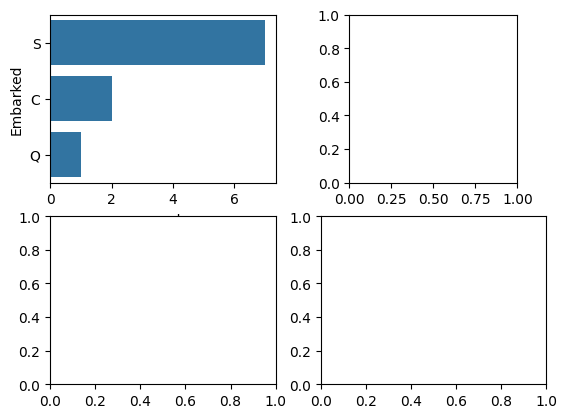

In [ ]:
plt.figure(figsize=(12, 8))
plt.subplots(2, 2)

plt.subplot(2,2,1)
ax = sns.countplot(df_transformed["Embarked"])

plt.subplot(2,2,2)
ax = plt.pie(df_transformed["Age"])

# plt.subplot(2,2,3)
# ax = sns.heatmap(df_transformed["Cabin"])

plt.show()

## Визуализация взаимосвязей между признаками

### Задание 5: Корреляционный анализ

Описание:
Вы анализируете датасет с финансовыми показателями компаний. Вам нужно понять, какие признаки сильнее всего коррелируют с целевой переменной.
Требования:

Используйте датасет S&P 500 Companies Financials.
Постройте:

Корреляционную матрицу (df.corr()).
Heatmap корреляций (sns.heatmap).

Определите:

Какие признаки имеют сильную корреляцию с целевой переменной?
Есть ли мультиколлинеарность между признаками?

Визуализируйте парные зависимости с помощью sns.pairplot.
Дополнительно:

Постройте графики рассеяния (sns.scatterplot) для признаков с высокой корреляцией.


In [ ]:
# https://www.kaggle.com/datasets/dgawlik/nyse

### Задание 6: Анализ временных рядов

Описание:
Вы анализируете датасет с данными о продажах за несколько лет. Вам нужно понять тренды и сезонность.
Требования:

Используйте датасет Store Sales Time Series.
Постройте графики:

Линейный график продаж по времени (plt.plot).
Разложение временного ряда на тренд, сезонность и остаток (seasonal_decompose из statsmodels).

Определите:

Есть ли тренд?
Есть ли сезонность?

Постройте автокорреляционную функцию (plot_acf из statsmodels).
Дополнительно:

Постройте скользящее среднее (rolling) для сглаживания временного ряда.


In [ ]:
# https://www.kaggle.com/c/store-sales-time-series-forecasting/data

## Продвинутые техники визуализации

### Задание 7: Интерактивные графики с Plotly

Описание:
Вы готовите дашборд для презентации результатов анализа. Вам нужно создать интерактивные графики.
Требования:

Используйте датасет COVID-19 Dataset.
Постройте интерактивные графики с помощью plotly:

Линейный график динамики заболеваемости по времени.
Карта распространения заболеваемости по регионам.
Bar plot распределения заболеваемости по возрастным группам.

Добавьте возможность фильтрации данных по регионам и временным периодам.
Дополнительно:

Сохраните графики в HTML-файл для дальнейшего использования.


In [ ]:
# https://www.kaggle.com/datasets/sudalairajkumar/covid19-in-india

### Задание 8: Визуализация многомерных данных

Описание:
Вы анализируете датасет с многомерными признаками. Вам нужно визуализировать данные в 2D/3D.
Требования:

Используйте датасет Iris или Wine Quality.
Постройте графики:

PCA для снижения размерности и визуализации в 2D (sklearn.decomposition.PCA).
t-SNE для визуализации кластеров (sklearn.manifold.TSNE).
3D-scatter plot (plotly или mpl_toolkits.mplot3d).

Проанализируйте, как хорошо разделяются классы после снижения размерности.
Дополнительно:

Постройте графики для анализа кластеров с помощью KMeans.


In [ ]:
# https://www.kaggle.com/datasets/uciml/iris
# https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009